In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import os

Dataset:
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  

Dataset Shape:
(418, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Na

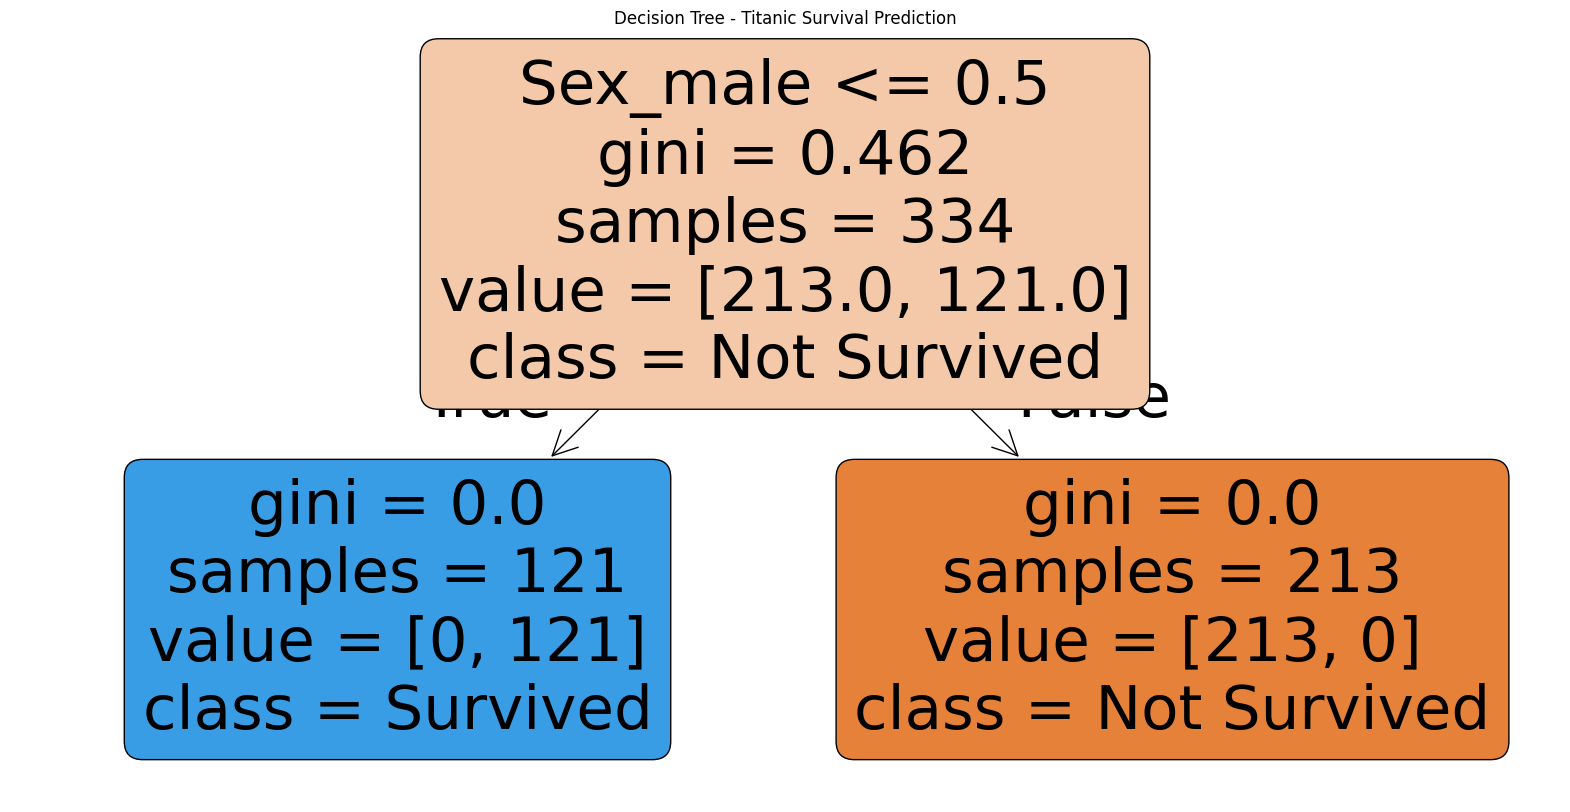

In [3]:
# ============================================================
# EXPERIMENT 8
# DECISION TREE CLASSIFICATION
# DATASET: TITANIC
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv('/content/drive/MyDrive/Colab/tested.csv')

print("Dataset:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 3. DATA PREPROCESSING
# ============================================================

# Drop columns that are not useful for prediction

df = df.drop(
    columns=['PassengerId', 'Name', 'Ticket', 'Cabin']
)


# Fill missing values

df['Age'] = df['Age'].fillna(
    df['Age'].median()
)

df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

df['Fare'] = df['Fare'].fillna(
    df['Fare'].median()
)


print("\nMissing values after preprocessing:")
print(df.isnull().sum())


# ============================================================
# 4. ENCODING CATEGORICAL VARIABLES
# ============================================================

df = pd.get_dummies(
    df,
    columns=['Sex', 'Embarked'],
    drop_first=True
)


print("\nDataset after encoding:")
print(df.head())


# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

X = df.drop(
    columns=['Survived']
)

y = df['Survived']


print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("Survived")


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("\nTraining data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)


# ============================================================
# 7. CREATE DECISION TREE MODEL
# ============================================================

decision_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)


# ============================================================
# 8. TRAIN THE MODEL
# ============================================================

decision_tree.fit(
    X_train,
    y_train
)

print("\nDecision Tree model trained successfully.")


# ============================================================
# 9. PREDICTION
# ============================================================

y_pred = decision_tree.predict(
    X_test
)


# ============================================================
# 10. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n============================================")
print("DECISION TREE CLASSIFICATION RESULTS")
print("============================================")

print(
    "Accuracy:",
    round(accuracy, 4)
)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Survived",
            "Survived"
        ]
    )
)


# ============================================================
# 13. VISUALIZE DECISION TREE
# ============================================================

plt.figure(
    figsize=(20, 10)
)

plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=[
        "Not Survived",
        "Survived"
    ],
    filled=True,
    rounded=True
)

plt.title(
    "Decision Tree - Titanic Survival Prediction"
)

plt.show()